In [15]:
import pandas as pd
import numpy as np
import jenkspy
from scipy.stats import kstest
import importlib

import plotly.express as px
import plotly.graph_objects as go
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt

from irina import utility_functions as uf

In [16]:
path = uf.PATH

In [17]:
year = 2023
df_country_subfield = pd.read_csv(path+f"df_country_subfield/individual_{year}.csv", index_col="country")
# df_country_subfield = pd.read_csv(path+"df_country_subfield_authors.csv", index_col="country")

In [18]:
df_country_subfield

,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3603,3604,3605,3607,3608,3609,3611,3612,3614,3616
country,,,,,,,,,,,,,,,,,,,,,
AD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AE,3.0,2.0,1.0,3.0,3.0,26.0,NaN,NaN,2.0,56.0,...,3.0,9.0,22.0,2.0,NaN,3.0,8.0,5.0,11.0,6.0
AF,1.0,5.0,3.0,2.0,1.0,1.0,NaN,NaN,NaN,15.0,...,NaN,NaN,2.0,NaN,NaN,2.0,NaN,3.0,NaN,1.0
AG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
AL,10.0,1.0,NaN,2.0,7.0,2.0,1.0,NaN,7.0,6.0,...,NaN,2.0,2.0,NaN,NaN,NaN,2.0,1.0,2.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YE,NaN,NaN,NaN,1.0,4.0,8.0,NaN,NaN,2.0,14.0,...,1.0,8.0,6.0,1.0,NaN,NaN,NaN,NaN,4.0,2.0
ZA,67.0,73.0,49.0,22.0,157.0,156.0,22.0,NaN,86.0,459.0,...,4.0,38.0,22.0,5.0,NaN,33.0,21.0,12.0,55.0,47.0


In [19]:
df_country_subfield_norm = (
    df_country_subfield
    .div(df_country_subfield.sum(axis=1), axis=0)
)

In [20]:
df_country_stats = (
    df_country_subfield
    .div(df_country_subfield.sum(axis=1), axis=0)
    .assign(
        entropy=lambda df: -df.mul(np.log(df)).sum(axis=1),
        norm_entropy=lambda df: df.entropy / np.log(len(df.columns) - 1),
        total_articles=df_country_subfield.sum(axis=1),
        log_total_articles=lambda df: np.log(df.total_articles),
        gini=df_country_subfield.apply(uf.gini, axis=1)
    )
    .merge(uf.df_country[["alpha-2", "alpha-3", "region"]], left_index=True, right_on="alpha-2", how="left")
    .rename(columns={"alpha-2": "country"})
    .set_index("country")
    .sort_values('total_articles', ascending=False)
    [["region", "entropy", "norm_entropy", "total_articles", "log_total_articles", "gini", "alpha-3"]]
)

In [21]:
df_country_stats

,region,entropy,norm_entropy,total_articles,log_total_articles,gini,alpha-3
country,,,,,,,
CN,Asia,4.527790,0.818853,771534.0,13.556136,0.706139,CHN
US,Americas,4.676791,0.845800,642572.0,13.373234,0.654047,USA
ID,Asia,3.698804,0.668931,264874.0,12.487010,0.855977,IDN
IN,Asia,4.708331,0.851504,235096.0,12.367749,0.652985,IND
DE,Europe,4.778026,0.864108,132503.0,11.794361,0.628929,DEU
...,...,...,...,...,...,...,...
FM,Oceania,0.693147,0.125356,2.0,0.693147,0.000000,FSM
GQ,Africa,0.693147,0.125356,2.0,0.693147,0.000000,GNQ
AW,Americas,-0.000000,-0.000000,1.0,0.000000,0.000000,ABW


# Pipeline

In [23]:
year_list = range(1970, 2023)
modes = ["individual", "collaborative"]
df_country_stats_yearly_list = []
for year_loop in year_list:
    for mode in modes:
        df_country_subfield = pd.read_csv(path+f"df_country_subfield/{mode}_{year_loop}.csv", index_col="country")
        df_country_subfield_norm = df_country_subfield.div(df_country_subfield.sum(axis=1), axis=0)
        df_country_stats_yearly_list.append(
            df_country_subfield
            .div(df_country_subfield.sum(axis=1), axis=0)
            .assign(
                entropy=lambda df: -df.mul(np.log(df)).sum(axis=1),
                norm_entropy=lambda df: df.entropy / np.log(len(df.columns) - 1),
                total_articles=df_country_subfield.sum(axis=1),
                log_total_articles=lambda df: np.log(df.total_articles),
                gini=df_country_subfield.apply(uf.gini, axis=1),
                year=year_loop,
                mode=mode
            )
            # .merge(uf.df_country[["alpha-2", "alpha-3", "region"]], left_index=True, right_on="alpha-2", how="left")
            # .rename(columns={"alpha-2": "country"})
            # .set_index("country")
            .reset_index(names="country")
            # .sort_values('total_articles', ascending=False)
            [["country", "mode", "year", "entropy", "norm_entropy", "total_articles", "log_total_articles", "gini"]]
        )
df_country_stats_yearly = pd.concat(df_country_stats_yearly_list)

In [24]:
df_country_stats_yearly.to_csv(uf.PATH+"df_country_stats_yearly.csv", index=False)

In [15]:
# df_country_stats.to_csv(path+f"df_country_stats_individual_{year}.csv")

# Size distribution

In [9]:
px.histogram(df_country_stats, x="log_total_articles", title="Number of Articles log-distribution")

In [10]:
# Example data
data = df_country_stats.log_total_articles.values

# KS test against standard normal
stat, p_value = kstest((data - data.mean()) / data.std(), 'norm')

print("KS statistic:", stat)
print("p-value:", p_value)
if p_value > 0.05:
    print("Normal distribution hypothesis is accepted")
else:
    print("Normal distribution hypothesis is rejected")

KS statistic: 0.05230458001954852
p-value: 0.5745067785540139
Normal distribution hypothesis is accepted


In [12]:
def get_stats_year(year, path="df_country_subfield/"):
    df_year = pd.read_csv(uf.PATH+path+f"{year}.csv", index_col="country")
    return (
        uf.get_country_stats(df_year)
        .assign(log_total_articles=lambda df: np.log(df.total_articles))
        .merge(uf.df_country[["alpha-2", "alpha-3", "region"]], left_index=True, right_on="alpha-2", how="left")
    )

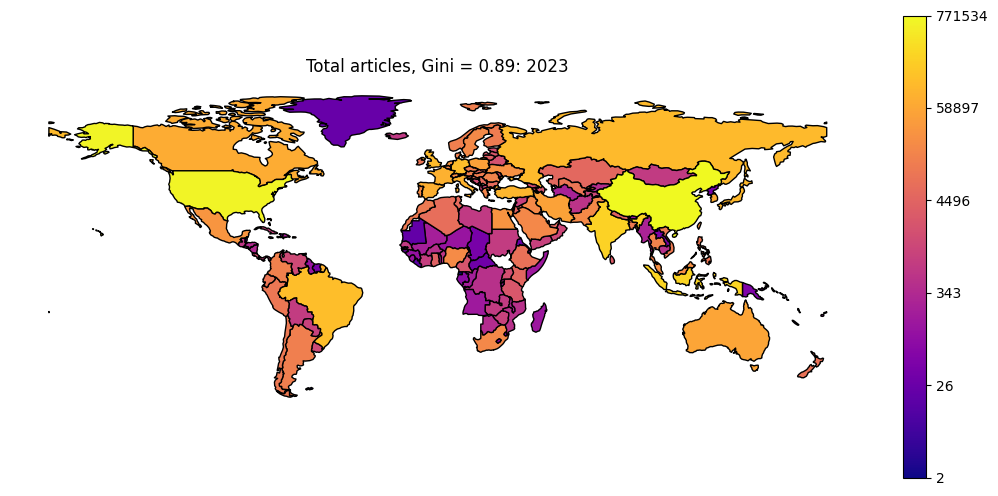

In [31]:
importlib.reload(uf)
year = 2023
df_stats = get_stats_year(year, path=f"df_country_subfield/individual_")

fig, ax = uf.plot_map_continuous(df_stats, "log_total_articles", title=f"Total articles, Gini = {round(uf.gini(df_stats.total_articles), 2)}:", year=year, log=True)
# fig.savefig(f"../images/map_total_articles_{year}.png")

In [98]:
# importlib.reload(uf)
#
# def animate_continuous(year):
#     # fig.clear()
#     df_year = get_stats_year(year, path="df_country_subfield/individual_")
#     _, _ = uf.plot_map_continuous(df_year, "log_total_articles", title="Total articles: ", year=year, log=True, fig=fig, ax=ax, range=(min, max))
#
#     # return ax

In [100]:
# years = range(1970, 2024)
#
# min=0
# max = get_stats_year(years[-1]).log_total_articles.max()
#
# fig, ax = plt.subplots(figsize=(12,6))
#
# animation = False
#
# anim = FuncAnimation(fig, animate_continuous, frames=years, interval=1000, blit=False)
#
# # Save as GIF
# # anim.save('map_animation.gif', writer='pillow', dpi=150)
#
# # Or save as MP4
# anim.save('../animations/log_total_articles_1970_2023.mp4', writer='ffmpeg', dpi=150)

In [16]:
uf.gini(df_stats.total_articles)

0.8666966673330023

In [110]:
df_plot = (
    df_country_stats
    .reset_index()
    .sort_values("total_articles")
    .assign(total_cumsum=lambda df: df.total_articles.cumsum())
)
px.scatter(df_plot, x="country", y="total_cumsum", color="region", category_orders={"country": df_plot["country"].tolist()},
           title="Lorenz curve (country productivity)")

# Heterogeneity statistics

The subfields probabilities seem to be distributed quite differently within different countries

In [33]:
df_country_stats

,region,entropy,norm_entropy,total_articles,log_total_articles,gini
country,,,,,,
CN,Asia,4.542577,0.821527,943754.0,13.757621,0.703687
US,Americas,4.737891,0.856850,893134.0,13.702492,0.642888
IN,Asia,4.710980,0.851983,286844.0,12.566694,0.655128
ID,Asia,3.759121,0.679839,280503.0,12.544340,0.846829
GB,Europe,4.840300,0.875371,243971.0,12.404805,0.614150
...,...,...,...,...,...,...
FM,Oceania,2.351673,0.425301,13.0,2.564949,0.125874
GQ,Africa,2.019815,0.365285,11.0,2.397895,0.170455
MP,Oceania,1.972247,0.356682,11.0,2.397895,0.215909


In [112]:
# importlib.reload(uf)
# year = 2023
# df_stats = get_stats_year(year, path="df_country_subfield/individual_")
#
# fig, ax = uf.plot_map_continuous(df_stats, "norm_entropy", title="Heterogeneity (Norm Entropy): ", year=year, log=False, range=(0, 1))

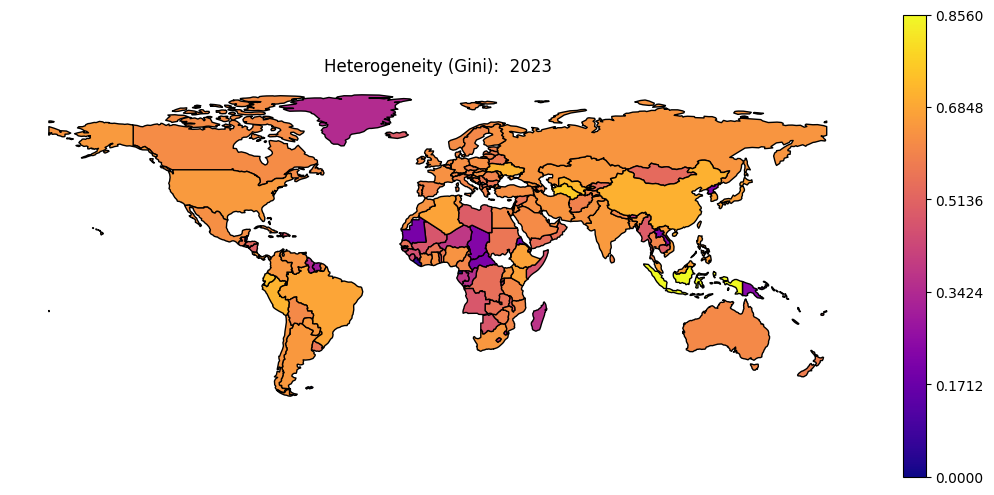

In [117]:
importlib.reload(uf)
year = 2023
df_stats = get_stats_year(year, path="df_country_subfield/individual_")

fig, ax = uf.plot_map_continuous(df_stats, "gini", title="Heterogeneity (Gini): ", year=year, log=False)

In [118]:
px.scatter(
    df_country_stats.reset_index(),
    x="log_total_articles",
    y="gini",
    title=f"Gini vs number of articles: {year} (smaller Gini -- less articles)",
    color="region",
    hover_name="country",
    hover_data=["region", "total_articles", "gini"],
)

In [113]:
# fig = px.bar(df_country_stats.reset_index(),
#              x="norm_entropy",
#              y="country",
#              title="Normalized entropy sorted by number of articles",
#              # color="region",
#              category_orders={"country": df_plot["country"].tolist()})
# fig.update_layout(height=800)

In [35]:
fig = px.bar(df_country_stats.reset_index(),
             x="gini",
             y="country",
             title="Gini sorted by number of articles",
             # color="region",
             category_orders={"country": df_plot["country"].tolist()})
fig.update_layout(height=800)

In [36]:
(
    df_country_stats
    # .query("gini > 0")
    # .query("total_articles > 400")
    .sort_values("gini", ascending=False)
    .merge(uf.df_country[["alpha-2", "name", "sub-region"]], left_index=True, right_on="alpha-2", how="left")
    .rename(columns={"alpha-2": "country"})
).head(10)

,region,entropy,norm_entropy,total_articles,log_total_articles,gini,country,name,sub-region
104,Asia,3.759121,0.679839,280503.0,12.544340,0.846829,ID,Indonesia,South-eastern Asia
228,Asia,2.145878,0.388083,280.0,5.634790,0.739429,TM,Turkmenistan,Central Asia
238,Asia,4.206524,0.760752,11156.0,9.319733,0.705285,UZ,Uzbekistan,Central Asia
45,Asia,4.542577,0.821527,943754.0,13.757621,0.703687,CN,China,Eastern Asia
64,Americas,4.325619,0.782290,13164.0,9.485241,0.701189,EC,Ecuador,Latin America and the Caribbean
232,Europe,4.498585,0.813571,33792.0,10.427979,0.697498,UA,Ukraine,Eastern Europe
3,Africa,4.408973,0.797365,10696.0,9.277625,0.697001,DZ,Algeria,Northern Africa
174,Americas,4.456133,0.805894,13786.0,9.531409,0.688663,PE,Peru,Latin America and the Caribbean
100,Asia,4.539179,0.820913,22868.0,10.037494,0.687975,HK,Hong Kong,Eastern Asia
231,Africa,4.295219,0.776793,4038.0,8.303505,0.683901,UG,Uganda,Sub-Saharan Africa


In [37]:
country = "VG"
px.bar(df_country_subfield.loc[country].to_frame(), title = uf.get_country_info(country).iloc[0, 0])

In [38]:
uf.get_subfield_info(3600)

,subfield_id,subfield_name,field_name,domain_name
311,3600,General Health Professions,Health Professions,Health Sciences


# Fisher breaks in heterogeneity statistics

In [41]:
breaks_gini = jenkspy.jenks_breaks(df_country_stats.gini, 7)

fig = go.Figure()

fig.add_trace(
    go.Histogram(x=df_country_stats.gini, nbinsx=100)
)
for x in breaks_gini:
    fig.add_vline(
        x=x,
        line=dict(color="red", width=2, dash="dash"),  # style of the line
        annotation_text=f"{x:.2f}",  # optional label
        annotation_position="top right"
    )
fig.update_layout(title="Gini histogram with Fisher breakpoints")
fig.show()

In [43]:
breaks_norm_entropy = jenkspy.jenks_breaks(df_country_stats.norm_entropy, 4)

fig = go.Figure()

fig.add_trace(
    go.Histogram(x=df_country_stats.norm_entropy, nbinsx=100)
)
for x in breaks_norm_entropy:
    fig.add_vline(
        x=x,
        line=dict(color="red", width=2, dash="dash"),  # style of the line
        annotation_text=f"{x:.2f}",  # optional label
        annotation_position="top right"
    )
fig.update_layout(title="Entropy histogram with Fisher breakpoints")
fig.show()